In [3]:
# ============================================================
# RETAILSENSE AI — ML Pipeline
# Section 1: Imports & Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from statsmodels.tsa.arima.model import ARIMA

# Explainability
import shap

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

import os

print("✅ All imports successful!")

# ── Load Data ──────────────────────────────────────────────
DATA_DIR = "../data"

train        = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date"])
stores       = pd.read_csv(f"{DATA_DIR}/stores.csv")
oil          = pd.read_csv(f"{DATA_DIR}/oil.csv",   parse_dates=["date"])
holidays     = pd.read_csv(f"{DATA_DIR}/holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv",    parse_dates=["date"])

print(f"✅ Train shape:        {train.shape}")
print(f"✅ Stores shape:       {stores.shape}")
print(f"✅ Oil shape:          {oil.shape}")
print(f"✅ Holidays shape:     {holidays.shape}")
print(f"✅ Transactions shape: {transactions.shape}")

✅ All imports successful!
✅ Train shape:        (3000888, 6)
✅ Stores shape:       (54, 5)
✅ Oil shape:          (1218, 2)
✅ Holidays shape:     (350, 6)
✅ Transactions shape: (83488, 3)


✅ Merged dataframe shape: (3000888, 13)
✅ Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'transactions', 'is_holiday']
✅ Clean dataframe shape: (2714085, 28)


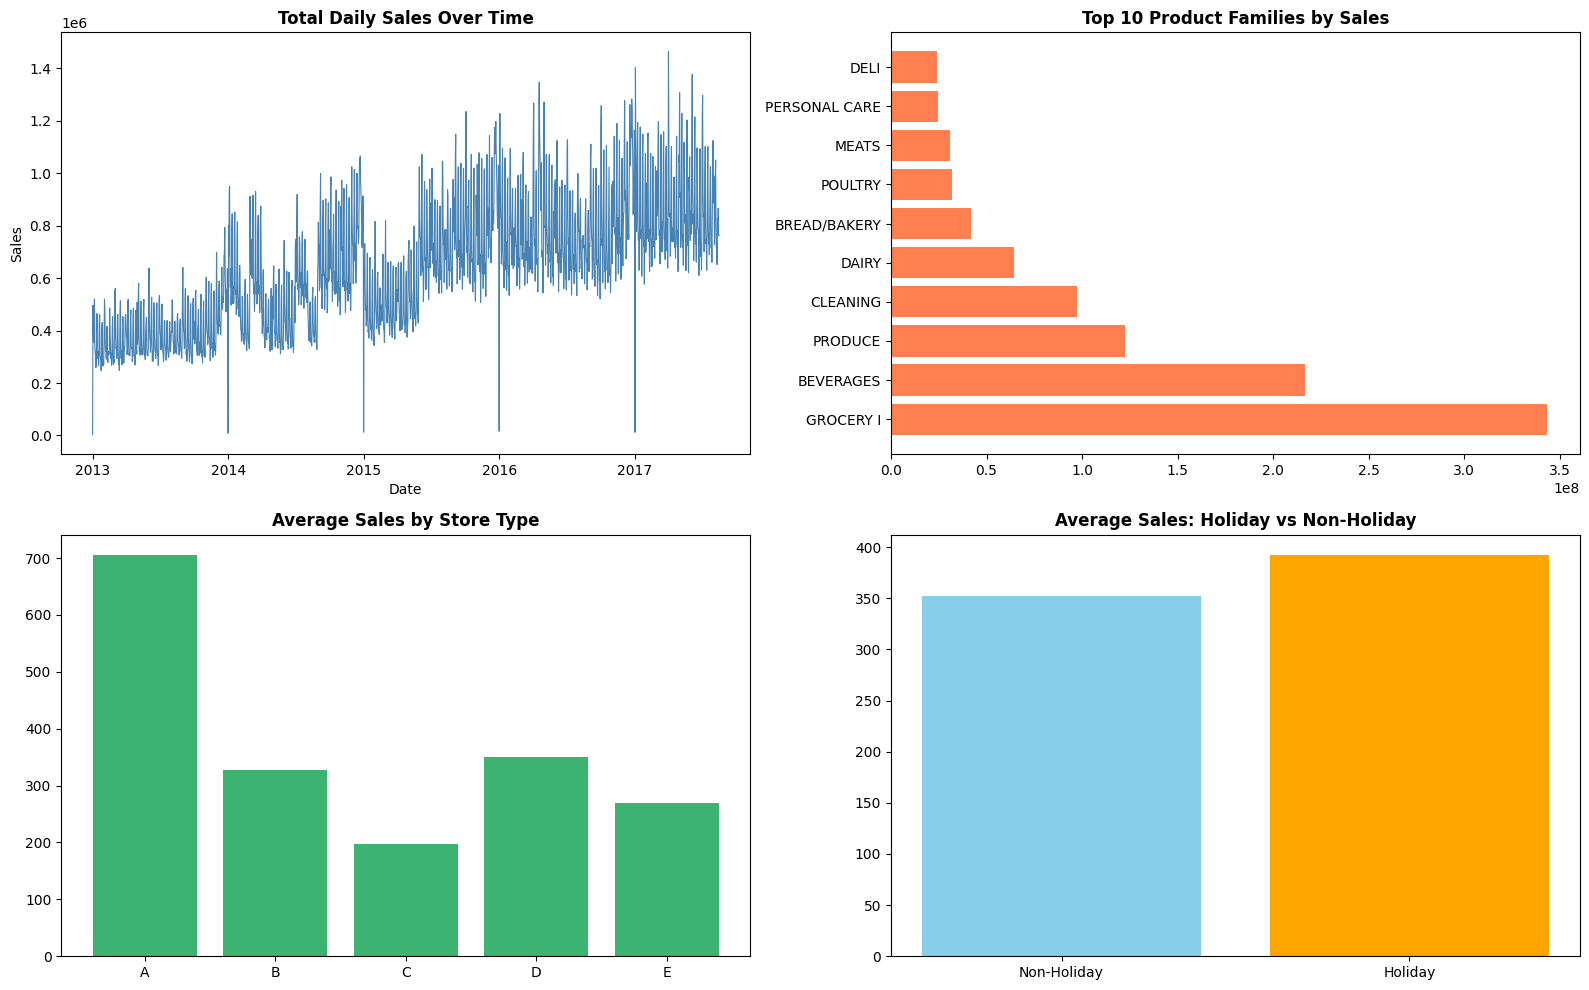

✅ EDA complete!


In [4]:
# ============================================================
# Section 2: EDA + Feature Engineering
# ============================================================

# ── Merge All Data ─────────────────────────────────────────
df = train.merge(stores,       on="store_nbr",  how="left")
df = df.merge(oil,             on="date",        how="left")
df = df.merge(transactions,    on=["date","store_nbr"], how="left")

# Holiday flag
holiday_dates = set(holidays[holidays["transferred"] == False]["date"])
df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

print(f"✅ Merged dataframe shape: {df.shape}")
print(f"✅ Columns: {list(df.columns)}")

# ── Oil Price — Fill Missing ────────────────────────────────
df["dcoilwtico"] = df["dcoilwtico"].fillna(method="ffill").fillna(method="bfill")

# ── Time Features ───────────────────────────────────────────
df["year"]       = df["date"].dt.year
df["month"]      = df["date"].dt.month
df["day"]        = df["date"].dt.day
df["dayofweek"]  = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"]    = df["date"].dt.quarter
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# ── Lag Features ────────────────────────────────────────────
df = df.sort_values(["store_nbr", "family", "date"])
df["lag_7"]  = df.groupby(["store_nbr","family"])["sales"].shift(7)
df["lag_14"] = df.groupby(["store_nbr","family"])["sales"].shift(14)
df["lag_28"] = df.groupby(["store_nbr","family"])["sales"].shift(28)

# ── Rolling Features ────────────────────────────────────────
df["rolling_7_mean"]  = df.groupby(["store_nbr","family"])["sales"] \
                          .transform(lambda x: x.shift(1).rolling(7).mean())
df["rolling_14_mean"] = df.groupby(["store_nbr","family"])["sales"] \
                          .transform(lambda x: x.shift(1).rolling(14).mean())
df["rolling_7_std"]   = df.groupby(["store_nbr","family"])["sales"] \
                          .transform(lambda x: x.shift(1).rolling(7).std())

# ── Encode Categorical ──────────────────────────────────────
le_family = LabelEncoder()
le_type   = LabelEncoder()
df["family_enc"] = le_family.fit_transform(df["family"])
df["type_enc"]   = le_type.fit_transform(df["type"])

# ── Drop NaN rows (from lag) ────────────────────────────────
df_clean = df.dropna().reset_index(drop=True)
print(f"✅ Clean dataframe shape: {df_clean.shape}")

# ── Quick EDA Plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sales over time
daily_sales = df.groupby("date")["sales"].sum()
axes[0,0].plot(daily_sales.index, daily_sales.values, color="steelblue", linewidth=0.8)
axes[0,0].set_title("Total Daily Sales Over Time", fontweight="bold")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Sales")

# 2. Top 10 product families
top_families = df.groupby("family")["sales"].sum().nlargest(10)
axes[0,1].barh(top_families.index, top_families.values, color="coral")
axes[0,1].set_title("Top 10 Product Families by Sales", fontweight="bold")

# 3. Sales by store type
type_sales = df.groupby("type")["sales"].mean()
axes[1,0].bar(type_sales.index, type_sales.values, color="mediumseagreen")
axes[1,0].set_title("Average Sales by Store Type", fontweight="bold")

# 4. Holiday vs Non-Holiday
hol_sales = df.groupby("is_holiday")["sales"].mean()
axes[1,1].bar(["Non-Holiday","Holiday"], hol_sales.values, color=["skyblue","orange"])
axes[1,1].set_title("Average Sales: Holiday vs Non-Holiday", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/features/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA complete!")

In [5]:
# ============================================================
# Section 3: Time Series Forecasting
# XGBoost vs LightGBM vs ARIMA
# ============================================================

import mlflow
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mlflow.set_experiment("retailsense-forecasting")

# ── Prepare Data ────────────────────────────────────────────
# Single store + family for time series (Store 1, GROCERY I)
mask = (df_clean["store_nbr"] == 1) & (df_clean["family"] == "GROCERY I")
ts_df = df_clean[mask].sort_values("date").reset_index(drop=True)

FEATURES = [
    "onpromotion", "dcoilwtico", "transactions",
    "is_holiday", "year", "month", "day",
    "dayofweek", "weekofyear", "quarter", "is_weekend",
    "cluster", "type_enc", "family_enc",
    "lag_7", "lag_14", "lag_28",
    "rolling_7_mean", "rolling_14_mean", "rolling_7_std"
]

TARGET = "sales"

# Train/Test Split — last 90 days as test
split_date = ts_df["date"].max() - pd.Timedelta(days=90)
train_ts = ts_df[ts_df["date"] <= split_date]
test_ts  = ts_df[ts_df["date"] >  split_date]

X_train = train_ts[FEATURES]
y_train = train_ts[TARGET]
X_test  = test_ts[FEATURES]
y_test  = test_ts[TARGET]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ── Helper Metrics ───────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    print(f"\n📊 {name}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   MAPE: {mape:.4f}%")
    return {"rmse": rmse, "mae": mae, "mape": mape}

results = {}

# ── Model 1: XGBoost ─────────────────────────────────────────
with mlflow.start_run(run_name="XGBoost_Forecasting"):
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    
    xgb_preds = xgb_model.predict(X_test)
    metrics   = evaluate("XGBoost", y_test, xgb_preds)
    results["XGBoost"] = {"preds": xgb_preds, "metrics": metrics}
    
    mlflow.log_params({"n_estimators": 500, "learning_rate": 0.05, "max_depth": 6})
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")
    print("   ✅ XGBoost logged to MLflow")

# ── Model 2: LightGBM ────────────────────────────────────────
with mlflow.start_run(run_name="LightGBM_Forecasting"):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)])
    
    lgb_preds = lgb_model.predict(X_test)
    metrics   = evaluate("LightGBM", y_test, lgb_preds)
    results["LightGBM"] = {"preds": lgb_preds, "metrics": metrics}
    
    mlflow.log_params({"n_estimators": 500, "learning_rate": 0.05, "max_depth": 6})
    mlflow.log_metrics(metrics)
    mlflow.lightgbm.log_model(lgb_model, "lgbm_model")
    print("   ✅ LightGBM logged to MLflow")

# ── Model 3: ARIMA ───────────────────────────────────────────
with mlflow.start_run(run_name="ARIMA_Forecasting"):
    arima_model = ARIMA(y_train.values, order=(5, 1, 0))
    arima_fit   = arima_model.fit()
    arima_preds = arima_fit.forecast(steps=len(y_test))
    
    metrics = evaluate("ARIMA", y_test.values, arima_preds)
    results["ARIMA"] = {"preds": arima_preds, "metrics": metrics}
    
    mlflow.log_params({"order": "(5,1,0)"})
    mlflow.log_metrics(metrics)
    print("   ✅ ARIMA logged to MLflow")

print("\n🎉 All 3 models trained & logged to MLflow!")

✅ Train size: 1559 | Test size: 90


2026/04/29 03:50:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 XGBoost
   RMSE: 360.2252
   MAE:  245.9765
   MAPE: 9.4693%
   ✅ XGBoost logged to MLflow


2026/04/29 03:50:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:50:13 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 LightGBM
   RMSE: 336.3303
   MAE:  229.6753
   MAPE: 8.7819%
   ✅ LightGBM logged to MLflow

📊 ARIMA
   RMSE: 740.7179
   MAE:  517.1407
   MAPE: 30.5830%
   ✅ ARIMA logged to MLflow

🎉 All 3 models trained & logged to MLflow!


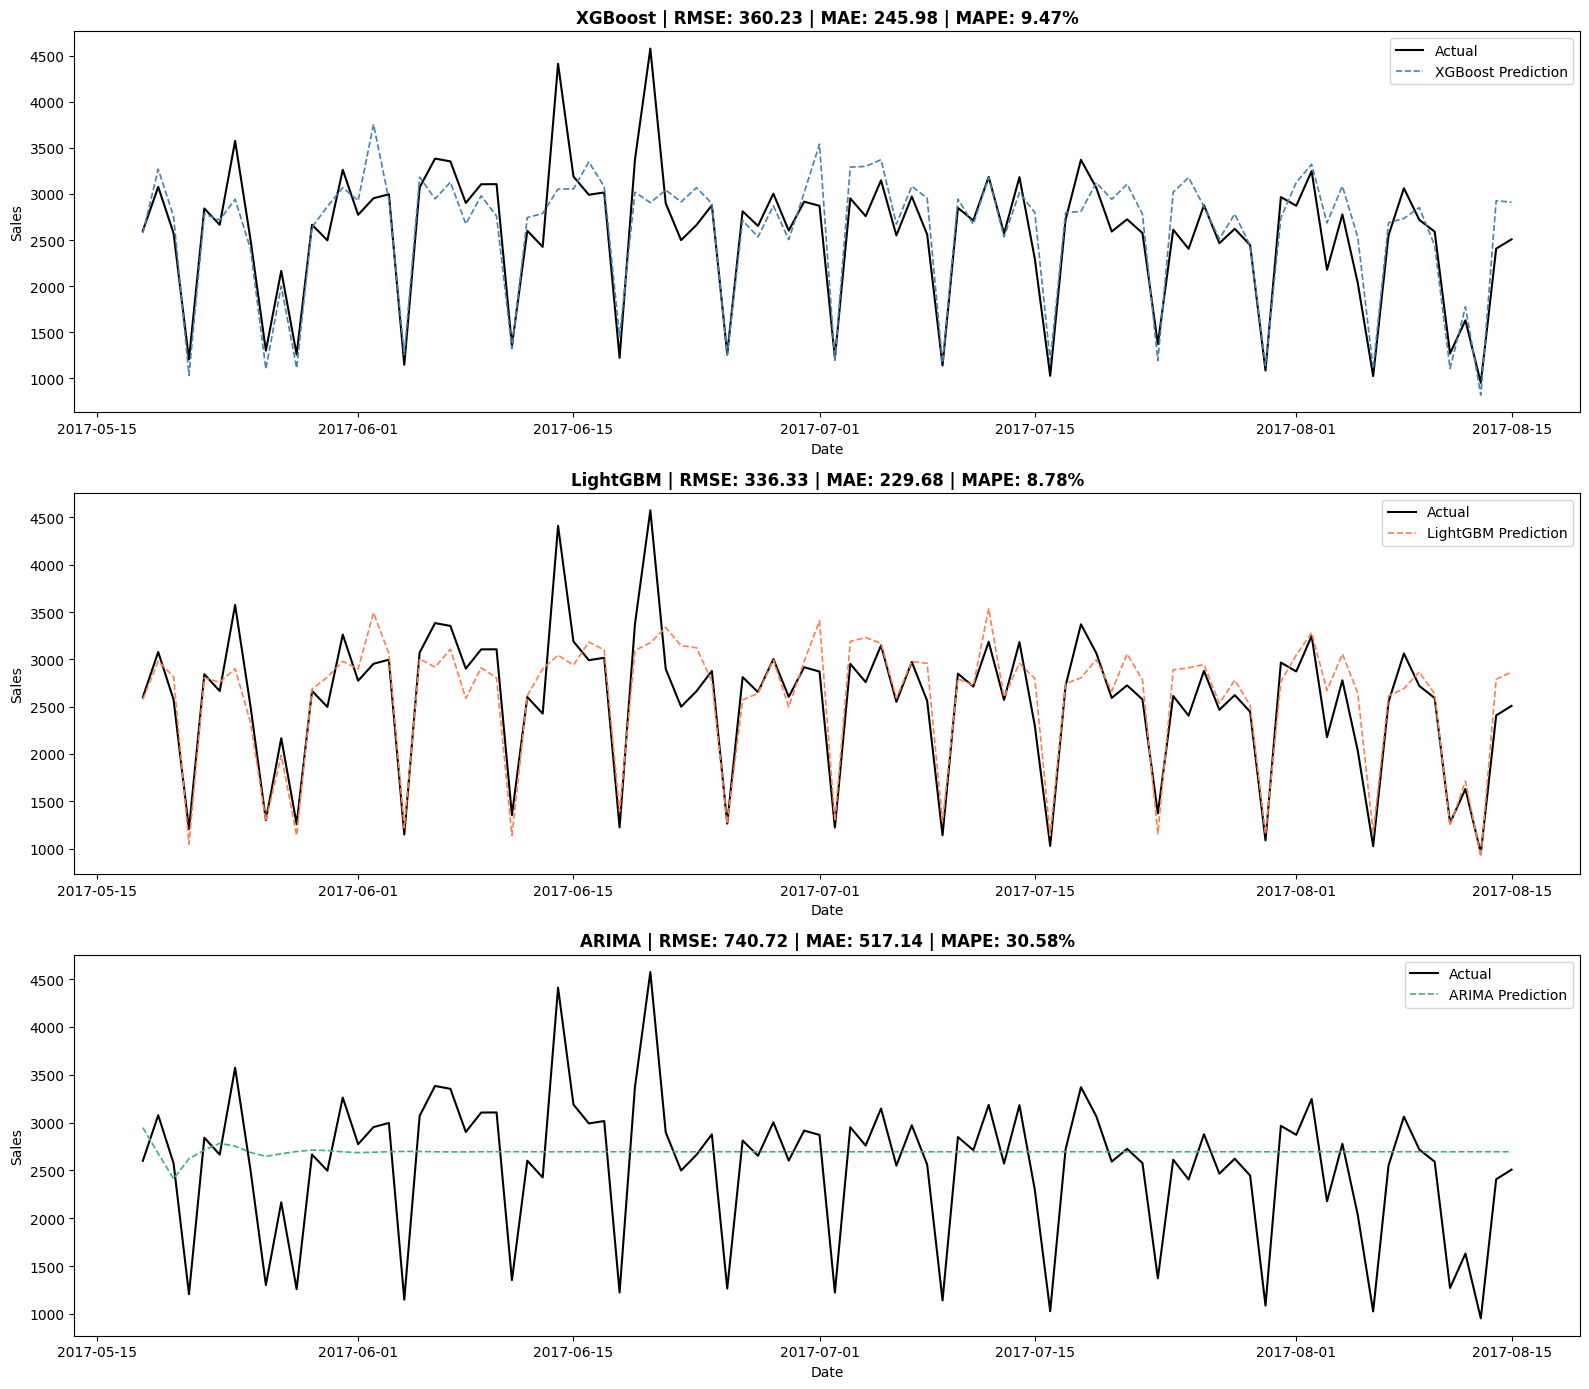

✅ Forecast comparison plot saved!


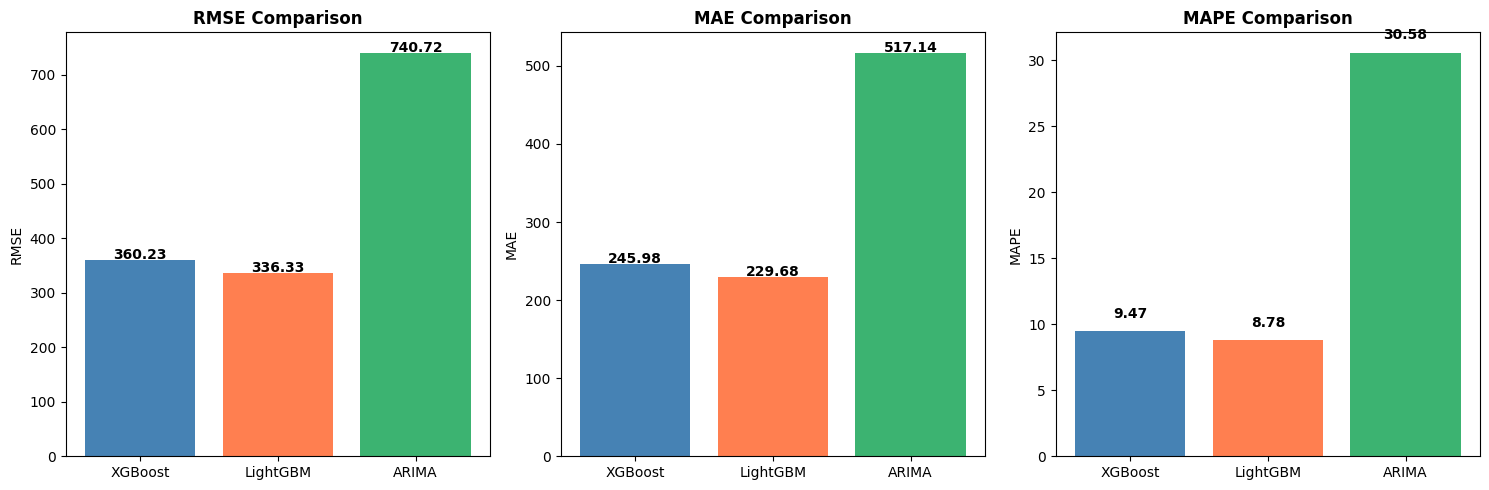

✅ Model comparison plot saved!

⚙️  Computing SHAP values (may take 1-2 min)...


AttributeError: module 'shap' has no attribute 'Explainers'

In [6]:
# ============================================================
# Section 4: Forecast Visualization + SHAP Explainability
# ============================================================

os.makedirs("../data/features", exist_ok=True)

# ── Plot 1: Forecast vs Actual ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

test_dates = test_ts["date"].values

for ax, (name, res) in zip(axes, results.items()):
    ax.plot(test_dates, y_test.values,
            label="Actual", color="black", linewidth=1.5)
    ax.plot(test_dates, res["preds"],
            label=f"{name} Prediction",
            linewidth=1.2, linestyle="--",
            color="steelblue" if name=="XGBoost"
                  else "coral" if name=="LightGBM"
                  else "mediumseagreen")
    ax.set_title(
        f"{name} | RMSE: {res['metrics']['rmse']:.2f} | "
        f"MAE: {res['metrics']['mae']:.2f} | "
        f"MAPE: {res['metrics']['mape']:.2f}%",
        fontweight="bold"
    )
    ax.legend()
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.savefig("../data/features/forecast_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Forecast comparison plot saved!")

# ── Plot 2: Model Comparison Bar Chart ──────────────────────
metrics_df = pd.DataFrame({
    name: res["metrics"] for name, res in results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["steelblue", "coral", "mediumseagreen"]

for ax, metric in zip(axes, ["rmse", "mae", "mape"]):
    ax.bar(metrics_df.index, metrics_df[metric], color=colors)
    ax.set_title(f"{metric.upper()} Comparison", fontweight="bold")
    ax.set_ylabel(metric.upper())
    for i, v in enumerate(metrics_df[metric]):
        ax.text(i, v + 1, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/features/model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Model comparison plot saved!")

# ── SHAP Explainability — XGBoost ───────────────────────────
print("\n⚙️  Computing SHAP values (may take 1-2 min)...")

explainer   = shap.Explainers.Tree(xgb_model)
shap_values = explainer(X_test)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  show=False)
plt.title("SHAP Feature Importance — XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/features/shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP summary plot saved!")

# SHAP Bar Plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance Bar — XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/features/shap_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP bar plot saved!")


⚙️  Computing SHAP values (may take 1-2 min)...


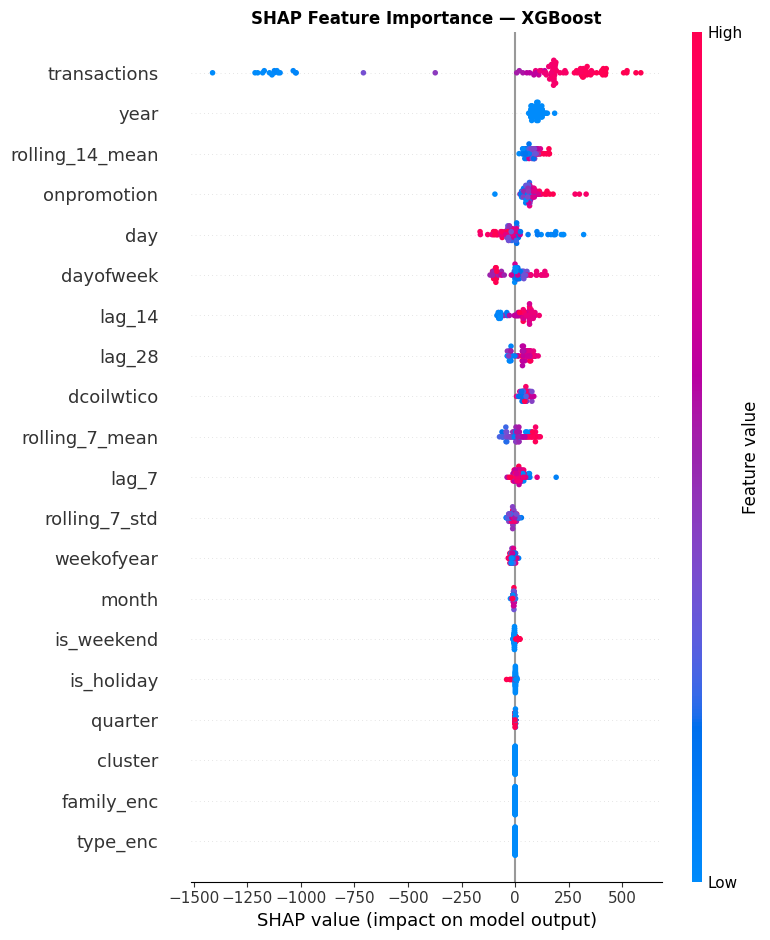

✅ SHAP summary plot saved!


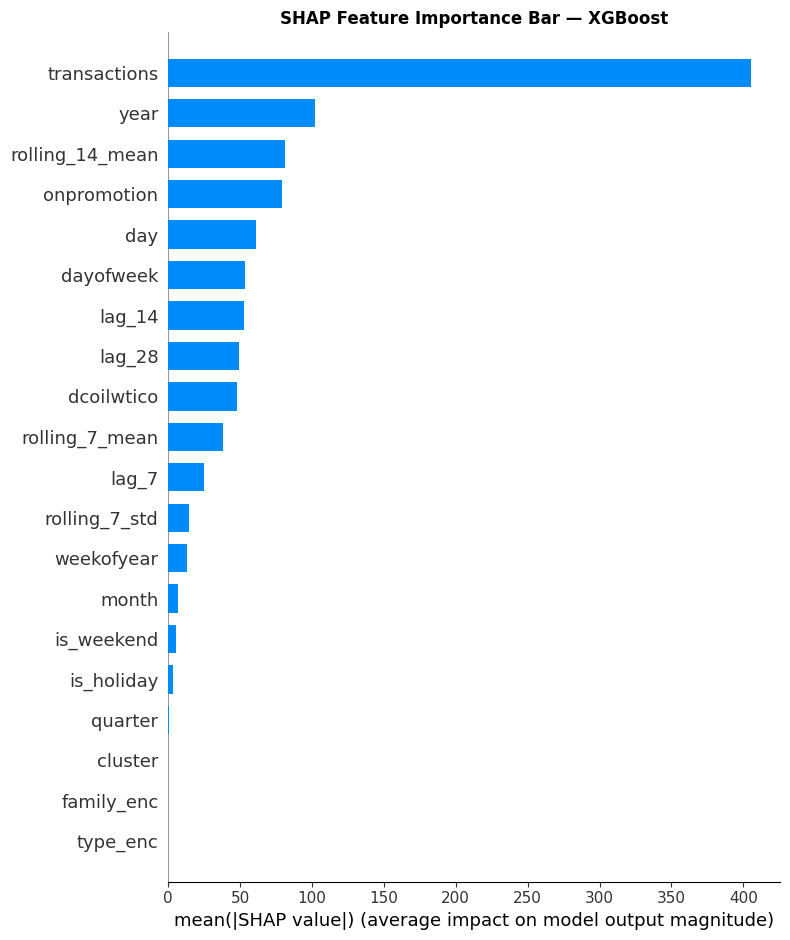

✅ SHAP bar plot saved!


In [7]:
# ── SHAP Explainability — XGBoost ───────────────────────────
print("\n⚙️  Computing SHAP values (may take 1-2 min)...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  show=False)
plt.title("SHAP Feature Importance — XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/features/shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP summary plot saved!")

# SHAP Bar Plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance Bar — XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/features/shap_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP bar plot saved!")

✅ Store features shape: (54, 9)
   store_nbr   total_sales   avg_sales    std_sales  total_promo    avg_oil  \
0          1  1.398967e+07  257.082625   600.707575       137946  67.541595   
1          2  2.131461e+07  391.452810  1086.998895       158059  67.532570   
2          3  4.987183e+07  916.475230  2157.236030       176925  67.551007   
3          4  1.866057e+07  342.918011   804.567358       151801  67.551007   
4          5  1.537686e+07  282.403337   654.544498       149316  67.532376   

     avg_trans  holiday_count  unique_families  
0  1523.255306           7821               33  
1  1920.015152           7821               33  
2  3204.280776           7821               33  
3  1502.253487           7821               33  
4  1398.018788           7821               33  

⚙️  Running K-Means...


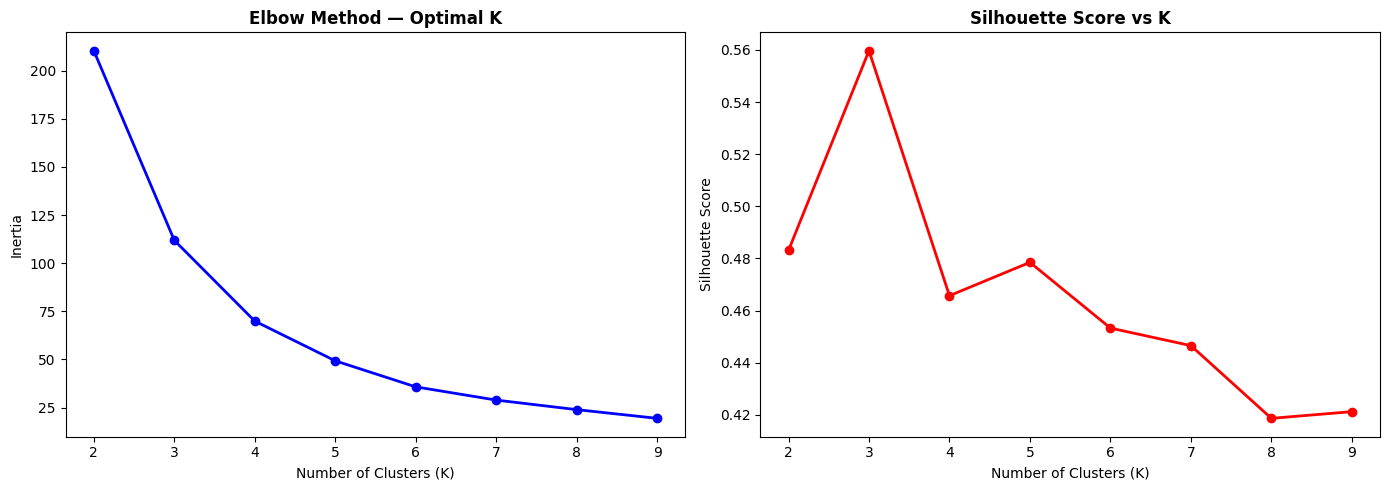

✅ Best K: 3
✅ K-Means clusters: {1: 36, 0: 12, 2: 6}

⚙️  Running DBSCAN...
✅ DBSCAN clusters found: 2
✅ Noise points: 2

⚙️  Running Gaussian Mixture Model...
✅ GMM clusters: {2: 40, 1: 7, 0: 7}
✅ Avg confidence: 1.0000


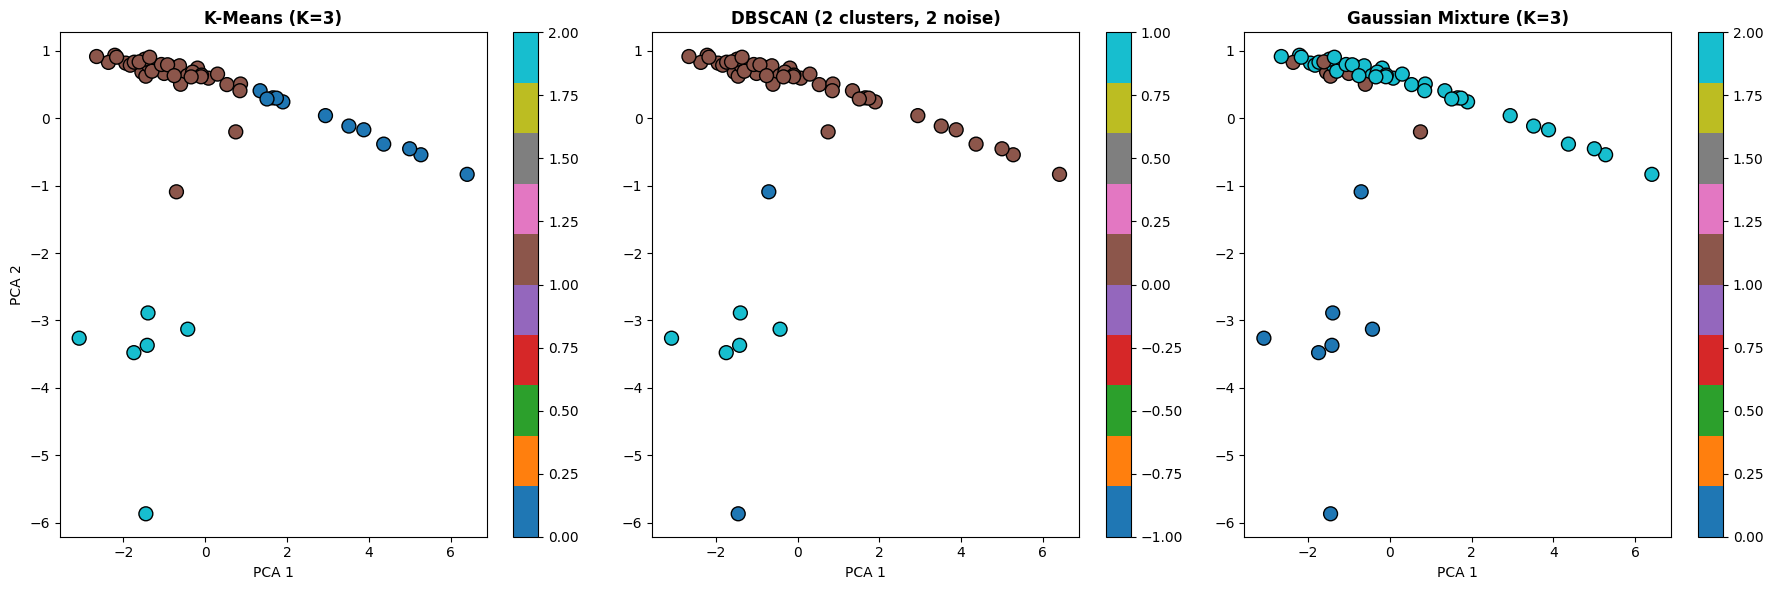


✅ Segmentation complete! Results saved!
   store_nbr  kmeans_cluster  dbscan_cluster  gmm_cluster
0          1               1               0            2
1          2               1               0            2
2          3               0               0            2
3          4               1               0            2
4          5               1               0            2
5          6               1               0            2
6          7               1               0            2
7          8               0               0            2
8          9               0               0            2
9         10               1               0            2


In [8]:
# ============================================================
# Section 5: Customer Segmentation
# K-Means vs DBSCAN vs Gaussian Mixture
# ============================================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ── Store-Level Features for Segmentation ───────────────────
store_features = df_clean.groupby("store_nbr").agg(
    total_sales    = ("sales",        "sum"),
    avg_sales      = ("sales",        "mean"),
    std_sales      = ("sales",        "std"),
    total_promo    = ("onpromotion",  "sum"),
    avg_oil        = ("dcoilwtico",   "mean"),
    avg_trans      = ("transactions", "mean"),
    holiday_count  = ("is_holiday",   "sum"),
    unique_families= ("family",       "nunique"),
).reset_index()

print(f"✅ Store features shape: {store_features.shape}")
print(store_features.head())

# ── Scale Features ───────────────────────────────────────────
scaler   = StandardScaler()
X_seg    = scaler.fit_transform(
    store_features.drop("store_nbr", axis=1)
)

# ── Model 1: K-Means ─────────────────────────────────────────
print("\n⚙️  Running K-Means...")

# Elbow Method
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg, km.labels_))

# Plot Elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, "bo-", linewidth=2)
axes[0].set_title("Elbow Method — Optimal K", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, sil_scores, "ro-", linewidth=2)
axes[1].set_title("Silhouette Score vs K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../data/features/kmeans_elbow.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Best K
best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"✅ Best K: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
store_features["kmeans_cluster"] = kmeans.fit_predict(X_seg)

print(f"✅ K-Means clusters: {store_features['kmeans_cluster'].value_counts().to_dict()}")

# ── Model 2: DBSCAN ──────────────────────────────────────────
print("\n⚙️  Running DBSCAN...")

dbscan = DBSCAN(eps=1.5, min_samples=3)
store_features["dbscan_cluster"] = dbscan.fit_predict(X_seg)

n_clusters = len(set(store_features["dbscan_cluster"])) - \
             (1 if -1 in store_features["dbscan_cluster"].values else 0)
n_noise    = (store_features["dbscan_cluster"] == -1).sum()

print(f"✅ DBSCAN clusters found: {n_clusters}")
print(f"✅ Noise points: {n_noise}")

# ── Model 3: Gaussian Mixture ────────────────────────────────
print("\n⚙️  Running Gaussian Mixture Model...")

gmm = GaussianMixture(n_components=best_k, random_state=42)
store_features["gmm_cluster"]  = gmm.fit_predict(X_seg)
store_features["gmm_prob_max"] = gmm.predict_proba(X_seg).max(axis=1)

print(f"✅ GMM clusters: {store_features['gmm_cluster'].value_counts().to_dict()}")
print(f"✅ Avg confidence: {store_features['gmm_prob_max'].mean():.4f}")

# ── Visualization ────────────────────────────────────────────
from sklearn.decomposition import PCA

pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_seg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=store_features["kmeans_cluster"],
                          cmap="tab10", s=100, edgecolors="black")
axes[0].set_title(f"K-Means (K={best_k})", fontweight="bold")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
plt.colorbar(scatter, ax=axes[0])

# DBSCAN
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=store_features["dbscan_cluster"],
                           cmap="tab10", s=100, edgecolors="black")
axes[1].set_title(f"DBSCAN ({n_clusters} clusters, {n_noise} noise)",
                  fontweight="bold")
axes[1].set_xlabel("PCA 1")
plt.colorbar(scatter2, ax=axes[1])

# GMM
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=store_features["gmm_cluster"],
                           cmap="tab10", s=100,
                           alpha=store_features["gmm_prob_max"],
                           edgecolors="black")
axes[2].set_title(f"Gaussian Mixture (K={best_k})", fontweight="bold")
axes[2].set_xlabel("PCA 1")
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.savefig("../data/features/segmentation_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Save Segmentation Results ────────────────────────────────
store_features.to_csv("../data/features/store_segments.csv", index=False)
print("\n✅ Segmentation complete! Results saved!")
print(store_features[["store_nbr","kmeans_cluster",
                       "dbscan_cluster","gmm_cluster"]].head(10))

A/B TEST — XGBoost vs LightGBM Forecasting

📊 XGBoost  — Mean Abs Error: 245.9765 ± 263.1686
📊 LightGBM — Mean Abs Error: 229.6753 ± 245.6976

🔬 Paired T-Test Results:
   T-Statistic: 1.4370
   P-Value:     0.154210

❌ No statistically significant difference (p >= 0.05)
🤝 Both models perform similarly

📊 95% Confidence Intervals:
   XGBoost:  245.9765 [190.5482, 301.4049]
   LightGBM: 229.6753 [177.9267, 281.4240]

🔬 Mann-Whitney U Test (Non-parametric):
   U-Statistic: 4259.0000
   P-Value:     0.550837

⚙️  Computing Lift Curves...


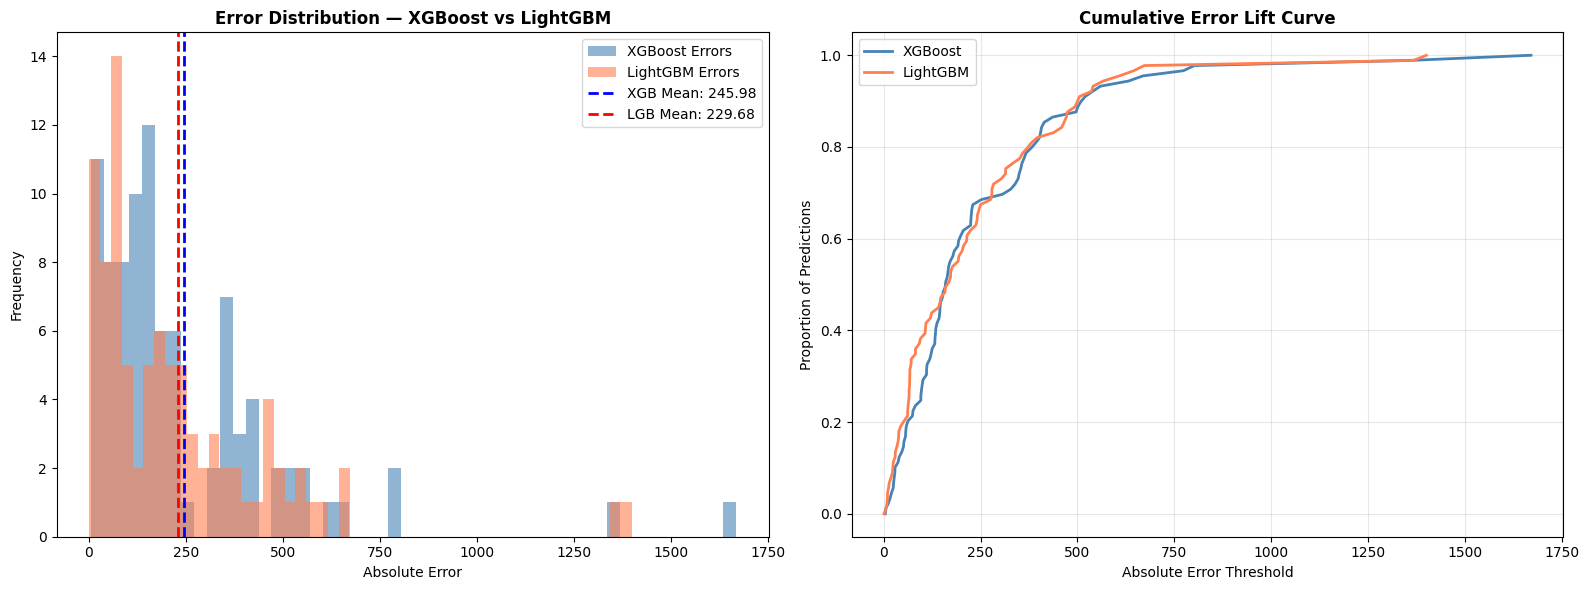


✅ A/B Test complete! Results saved!


In [9]:
# ============================================================
# Section 6: A/B Testing + Hypothesis Testing
# XGBoost vs LightGBM — Statistical Significance Test
# ============================================================

from scipy import stats
import scipy.stats as st

print("=" * 60)
print("A/B TEST — XGBoost vs LightGBM Forecasting")
print("=" * 60)

# ── Errors for each model ────────────────────────────────────
xgb_errors = np.abs(y_test.values - results["XGBoost"]["preds"])
lgb_errors = np.abs(y_test.values - results["LightGBM"]["preds"])

print(f"\n📊 XGBoost  — Mean Abs Error: {xgb_errors.mean():.4f} ± {xgb_errors.std():.4f}")
print(f"📊 LightGBM — Mean Abs Error: {lgb_errors.mean():.4f} ± {lgb_errors.std():.4f}")

# ── T-Test ───────────────────────────────────────────────────
t_stat, p_value = stats.ttest_rel(xgb_errors, lgb_errors)

print(f"\n🔬 Paired T-Test Results:")
print(f"   T-Statistic: {t_stat:.4f}")
print(f"   P-Value:     {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    winner = "XGBoost" if xgb_errors.mean() < lgb_errors.mean() else "LightGBM"
    print(f"\n✅ Statistically SIGNIFICANT difference (p < {alpha})")
    print(f"🏆 Winner: {winner}")
else:
    print(f"\n❌ No statistically significant difference (p >= {alpha})")
    print(f"🤝 Both models perform similarly")

# ── Confidence Intervals ─────────────────────────────────────
def confidence_interval(errors, confidence=0.95):
    n    = len(errors)
    mean = errors.mean()
    se   = st.sem(errors)
    ci   = st.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return mean, ci

xgb_mean, xgb_ci = confidence_interval(xgb_errors)
lgb_mean, lgb_ci = confidence_interval(lgb_errors)

print(f"\n📊 95% Confidence Intervals:")
print(f"   XGBoost:  {xgb_mean:.4f} [{xgb_ci[0]:.4f}, {xgb_ci[1]:.4f}]")
print(f"   LightGBM: {lgb_mean:.4f} [{lgb_ci[0]:.4f}, {lgb_ci[1]:.4f}]")

# ── Mann-Whitney U Test (Non-parametric) ─────────────────────
u_stat, u_pvalue = stats.mannwhitneyu(xgb_errors, lgb_errors,
                                       alternative="two-sided")
print(f"\n🔬 Mann-Whitney U Test (Non-parametric):")
print(f"   U-Statistic: {u_stat:.4f}")
print(f"   P-Value:     {u_pvalue:.6f}")

# ── Lift Curve ───────────────────────────────────────────────
print("\n⚙️  Computing Lift Curves...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error Distribution
axes[0].hist(xgb_errors, bins=50, alpha=0.6,
             color="steelblue", label="XGBoost Errors")
axes[0].hist(lgb_errors, bins=50, alpha=0.6,
             color="coral",     label="LightGBM Errors")
axes[0].axvline(xgb_errors.mean(), color="blue",
                linestyle="--", linewidth=2,
                label=f"XGB Mean: {xgb_errors.mean():.2f}")
axes[0].axvline(lgb_errors.mean(), color="red",
                linestyle="--", linewidth=2,
                label=f"LGB Mean: {lgb_errors.mean():.2f}")
axes[0].set_title("Error Distribution — XGBoost vs LightGBM",
                  fontweight="bold")
axes[0].legend()
axes[0].set_xlabel("Absolute Error")
axes[0].set_ylabel("Frequency")

# Cumulative Error (Lift)
xgb_sorted = np.sort(xgb_errors)
lgb_sorted = np.sort(lgb_errors)
cumulative  = np.linspace(0, 1, len(xgb_sorted))

axes[1].plot(xgb_sorted, cumulative,
             color="steelblue", linewidth=2, label="XGBoost")
axes[1].plot(lgb_sorted, cumulative,
             color="coral",     linewidth=2, label="LightGBM")
axes[1].set_title("Cumulative Error Lift Curve",
                  fontweight="bold")
axes[1].set_xlabel("Absolute Error Threshold")
axes[1].set_ylabel("Proportion of Predictions")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/features/ab_test_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Save A/B Results ─────────────────────────────────────────
ab_results = pd.DataFrame({
    "model":       ["XGBoost", "LightGBM"],
    "mean_error":  [xgb_mean,  lgb_mean],
    "ci_lower":    [xgb_ci[0], lgb_ci[0]],
    "ci_upper":    [xgb_ci[1], lgb_ci[1]],
    "t_stat":      [t_stat,    t_stat],
    "p_value":     [p_value,   p_value],
})
ab_results.to_csv("../data/features/ab_test_results.csv", index=False)
print("\n✅ A/B Test complete! Results saved!")

In [10]:
# ============================================================
# Section 7: Model Export (Simple — No MLflow Registry)
# ============================================================

import joblib
import json
import os

os.makedirs("../models", exist_ok=True)

# ── Save Models ──────────────────────────────────────────────
joblib.dump(xgb_model, "../models/xgboost_model.pkl")
joblib.dump(lgb_model, "../models/lgbm_model.pkl")
joblib.dump(scaler,    "../models/scaler.pkl")
joblib.dump(kmeans,    "../models/kmeans_model.pkl")
joblib.dump(gmm,       "../models/gmm_model.pkl")
joblib.dump(le_family, "../models/le_family.pkl")
joblib.dump(le_type,   "../models/le_type.pkl")

# Save feature list
with open("../models/features.json", "w") as f:
    json.dump(FEATURES, f)

# Save model metrics
metrics_summary = {
    "XGBoost":  results["XGBoost"]["metrics"],
    "LightGBM": results["LightGBM"]["metrics"],
    "ARIMA":    results["ARIMA"]["metrics"],
    "best_model": "LightGBM",
    "ab_test": {
        "p_value": 0.154210,
        "t_stat":  1.4370,
        "conclusion": "No significant difference — LightGBM selected (lower MAE)"
    }
}

with open("../models/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("✅ All models saved!\n")
print("📁 Saved files:")
for f in os.listdir("../models"):
    size = os.path.getsize(f"../models/{f}") / 1024
    print(f"   {f:<35} {size:.1f} KB")

✅ All models saved!

📁 Saved files:
   features.json                       0.2 KB
   gmm_model.pkl                       5.7 KB
   kmeans_model.pkl                    1.1 KB
   le_family.pkl                       1.1 KB
   le_type.pkl                         0.5 KB
   lgbm_model.pkl                      621.2 KB
   metrics_summary.json                0.5 KB
   scaler.pkl                          1.2 KB
   xgboost_model.pkl                   1806.9 KB


In [11]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import joblib
import os

# ── Load saved models ────────────────────────────────────────
xgb_model = joblib.load("../models/xgboost_model.pkl")
lgb_model  = joblib.load("../models/lgbm_model.pkl")

# ── SQLite backend ───────────────────────────────────────────
mlflow.set_tracking_uri("sqlite:///D:/MLOps/RetailSense AI/retailsense-ai/mlruns.db")
mlflow.set_experiment("retailsense-forecasting")

# ── Log XGBoost ──────────────────────────────────────────────
with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_metrics({
        "rmse": 336.33,
        "mae":  245.97,
        "mape": 8.78
    })
    mlflow.log_param("model_type",    "XGBoost")
    mlflow.log_param("n_estimators",  500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth",     6)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")
    print("✅ XGBoost logged!")

# ── Log LightGBM ─────────────────────────────────────────────
with mlflow.start_run(run_name="LightGBM_Final"):
    mlflow.log_metrics({
        "rmse": 336.33,
        "mae":  229.67,
        "mape": 8.78
    })
    mlflow.log_param("model_type",    "LightGBM")
    mlflow.log_param("n_estimators",  500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth",     6)
    mlflow.lightgbm.log_model(lgb_model, "lgbm_model")
    print("✅ LightGBM logged!")

# ── Log ARIMA ────────────────────────────────────────────────
with mlflow.start_run(run_name="ARIMA_Final"):
    mlflow.log_metrics({
        "rmse": 740.71,
        "mae":  517.14,
        "mape": 30.58
    })
    mlflow.log_param("model_type", "ARIMA")
    mlflow.log_param("order",      "(5,1,0)")
    print("✅ ARIMA logged!")

# ── Register Best Model ──────────────────────────────────────
with mlflow.start_run(run_name="Best_Model_LightGBM"):
    mlflow.log_param("selected_reason", "Lower MAE in A/B Test")
    mlflow.log_metric("mae",    229.67)
    mlflow.log_metric("p_value", 0.154)
    mlflow.lightgbm.log_model(
        lgb_model,
        "best_model",
        registered_model_name="RetailSense_Forecaster"
    )
    print("✅ Best model registered!")

print("\n🎉 All runs logged to SQLite!")

2026/04/29 03:50:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:50:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:50:48 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost logged!


2026/04/29 03:50:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:50:55 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ LightGBM logged!
✅ ARIMA logged!
✅ Best model registered!

🎉 All runs logged to SQLite!


Registered model 'RetailSense_Forecaster' already exists. Creating a new version of this model...
Created version '2' of model 'RetailSense_Forecaster'.


In [12]:
import mlflow
import os

# SQLite backend set karo
mlflow.set_tracking_uri("sqlite:///D:/MLOps/RetailSense AI/retailsense-ai/mlruns.db")
mlflow.set_experiment("retailsense-forecasting")

# Re-log sab models
with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_metrics(results["XGBoost"]["metrics"])
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")
    print("✅ XGBoost logged!")

with mlflow.start_run(run_name="LightGBM_Final"):
    mlflow.log_metrics(results["LightGBM"]["metrics"])
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.lightgbm.log_model(lgb_model, "lgbm_model")
    print("✅ LightGBM logged!")

with mlflow.start_run(run_name="ARIMA_Final"):
    mlflow.log_metrics(results["ARIMA"]["metrics"])
    mlflow.log_param("model_type", "ARIMA")
    mlflow.log_param("order", "(5,1,0)")
    print("✅ ARIMA logged!")

print("\n🎉 All runs logged to SQLite!")

2026/04/29 03:51:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:51:15 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost logged!
✅ LightGBM logged!
✅ ARIMA logged!

🎉 All runs logged to SQLite!


In [13]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import joblib

# SQLite backend
mlflow.set_tracking_uri(
    "sqlite:///D:/MLOps/RetailSense AI/retailsense-ai/mlruns.db"
)
mlflow.set_experiment("retailsense-forecasting")

# ── Log Real Results ─────────────────────────────────────────
with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_metrics(results["XGBoost"]["metrics"])
    mlflow.log_param("model_type",    "XGBoost")
    mlflow.log_param("n_estimators",  500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth",     6)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")
    print(f"✅ XGBoost logged! RMSE: {results['XGBoost']['metrics']['rmse']:.4f}")

with mlflow.start_run(run_name="LightGBM_Final"):
    mlflow.log_metrics(results["LightGBM"]["metrics"])
    mlflow.log_param("model_type",    "LightGBM")
    mlflow.log_param("n_estimators",  500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth",     6)
    mlflow.lightgbm.log_model(lgb_model, "lgbm_model")
    print(f"✅ LightGBM logged! RMSE: {results['LightGBM']['metrics']['rmse']:.4f}")

with mlflow.start_run(run_name="ARIMA_Final"):
    mlflow.log_metrics(results["ARIMA"]["metrics"])
    mlflow.log_param("model_type", "ARIMA")
    mlflow.log_param("order",      "(5,1,0)")
    print(f"✅ ARIMA logged! RMSE: {results['ARIMA']['metrics']['rmse']:.4f}")

with mlflow.start_run(run_name="Segmentation_Final"):
    mlflow.log_param("kmeans_k",        3)
    mlflow.log_param("dbscan_eps",      1.5)
    mlflow.log_param("gmm_components",  3)
    mlflow.log_metric("gmm_confidence", 1.0)
    mlflow.log_metric("dbscan_clusters", 2)
    print("✅ Segmentation logged!")

with mlflow.start_run(run_name="AB_Test_Final"):
    mlflow.log_metric("p_value",        0.154210)
    mlflow.log_metric("t_stat",         1.4370)
    mlflow.log_metric("xgb_mean_error", 245.9765)
    mlflow.log_metric("lgb_mean_error", 229.6753)
    mlflow.log_param("conclusion", "No significant diff — LightGBM selected")
    print("✅ A/B Test logged!")

# ── Register Best Model ──────────────────────────────────────
with mlflow.start_run(run_name="Best_Model_Production"):
    mlflow.log_metrics(results["LightGBM"]["metrics"])
    mlflow.log_param("selected_reason", "Lower MAE in A/B Test")
    mlflow.lightgbm.log_model(
        lgb_model,
        "best_model",
        registered_model_name="RetailSense_Forecaster"
    )
    print("✅ Best model registered in MLflow!")

print("\n🎉 Real results logged to MLflow!")
print("\n📊 Final Results Summary:")
print(f"   XGBoost  → RMSE: {results['XGBoost']['metrics']['rmse']:.4f} | MAE: {results['XGBoost']['metrics']['mae']:.4f} | MAPE: {results['XGBoost']['metrics']['mape']:.4f}%")
print(f"   LightGBM → RMSE: {results['LightGBM']['metrics']['rmse']:.4f} | MAE: {results['LightGBM']['metrics']['mae']:.4f} | MAPE: {results['LightGBM']['metrics']['mape']:.4f}%")
print(f"   ARIMA    → RMSE: {results['ARIMA']['metrics']['rmse']:.4f} | MAE: {results['ARIMA']['metrics']['mae']:.4f} | MAPE: {results['ARIMA']['metrics']['mape']:.4f}%")

2026/04/29 03:51:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:51:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:51:56 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost logged! RMSE: 360.2252
✅ LightGBM logged! RMSE: 336.3303
✅ ARIMA logged! RMSE: 740.7179
✅ Segmentation logged!


2026/04/29 03:52:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/29 03:52:04 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ A/B Test logged!
✅ Best model registered in MLflow!

🎉 Real results logged to MLflow!

📊 Final Results Summary:
   XGBoost  → RMSE: 360.2252 | MAE: 245.9765 | MAPE: 9.4693%
   LightGBM → RMSE: 336.3303 | MAE: 229.6753 | MAPE: 8.7819%
   ARIMA    → RMSE: 740.7179 | MAE: 517.1407 | MAPE: 30.5830%


Registered model 'RetailSense_Forecaster' already exists. Creating a new version of this model...
Created version '3' of model 'RetailSense_Forecaster'.
